# Normalized Data Exploration
This notebook provides:
- Document counts by collection, tier, and phase
- Text quality metrics (word count, character distribution)
- Extraction mode breakdown (article vs fallback)
- Fetch status health check
- Top domains per tier and phase

In [48]:
import json
from pathlib import Path
from collections import Counter, defaultdict
from urllib.parse import urlparse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Viridis aesthetic -----
viridis_palette = sns.color_palette("viridis")

sns.set_style("whitegrid", {
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#ffffff",
    "grid.color": "#e0e0e0",
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

sns.set_palette(viridis_palette)

sns.set_context("notebook", font_scale=1.3, rc={
    "lines.linewidth": 2,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
})

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

In [49]:
# Paths and config
from config import PROCESSED_DIR, COVID_COLLECTIONS, PHASES_BY_NAME

NORMALIZED_DIR = PROCESSED_DIR / "normalized"
print(f"Normalized dir: {NORMALIZED_DIR}")

Normalized dir: C:\code\credleaf\data\processed\normalized


In [50]:
def load_normalized_docs(normalized_dir: Path) -> list[dict]:
    """Load all normalized JSONL files into a flat list."""
    docs = []
    for jsonl_path in sorted(normalized_dir.rglob("*.jsonl")):
        print(f"Loading {jsonl_path.relative_to(PROCESSED_DIR)}")
        with jsonl_path.open("r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                docs.append(json.loads(line))
    return docs

docs = load_normalized_docs(NORMALIZED_DIR)
print(f"\nLoaded {len(docs)} documents")

Loading normalized\13559\P1_first_wave.jsonl
Loading normalized\13559\P1_global_onset.jsonl
Loading normalized\4887\P0_outbreak.jsonl
Loading normalized\4887\P1_global_onset.jsonl
Loading normalized\4887\P2_pre_vaccine.jsonl
Loading normalized\4887\P3_vaccine_rollout.jsonl
Loading normalized\4887\P4_delta_wave.jsonl
Loading normalized\4887\P5_omicron_wave.jsonl
Loading normalized\4887\P6_transition_end.jsonl

Loaded 6494 documents


In [51]:
# Build dataframe for easier analysis
df = pd.DataFrame(docs)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Shape: (6494, 17)

Columns: ['collection_id', 'seed_id', 'seed_url', 'phase', 'capture_timestamp', 'capture_url', 'digest', 'fetched_at', 'fetch_status', 'error', 'title', 'text', 'language', 'publish_date', 'word_count', 'char_count', 'extraction_mode']

Data types:
collection_id         int64
seed_id               int64
seed_url                str
phase                   str
capture_timestamp       str
capture_url             str
digest                  str
fetched_at              str
fetch_status            str
error                   str
title                   str
text                    str
language             object
publish_date            str
word_count            int64
char_count            int64
extraction_mode         str
dtype: object


In [52]:
# Add credibility tier lookup
from credibility.registry import CredibilityRegistry, normalize_host

# Try to load pre-built registry if available, otherwise mark as unknown
registry_path = PROCESSED_DIR.parent / "credibility_registry.json"
if registry_path.exists():
    registry = CredibilityRegistry.load(registry_path)
    print(f"Loaded credibility registry: {registry}")
else:
    registry = CredibilityRegistry()
    print("No credibility registry found; using collection tier fallback")

# Fallback: use collection tier from config
def get_tier(row):
    tier = registry.lookup(row["seed_url"])
    if tier == "unknown":
        # Fall back to collection tier from config
        coll = COVID_COLLECTIONS.get(row["collection_id"])
        tier = coll.credibility_tier if coll else "unknown"
    return tier

df["tier"] = df.apply(get_tier, axis=1)
print(f"\nTier distribution:\n{df['tier'].value_counts()}")

No credibility registry found; using collection tier fallback

Tier distribution:
tier
low      5976
mixed     518
Name: count, dtype: int64


## 1. Overview Statistics

In [53]:
# Document count by collection and phase
print("\n=== Document Counts ===")
print(f"\nTotal documents: {len(df)}")
print(f"Unique collections: {df['collection_id'].nunique()}")
print(f"Unique phases: {df['phase'].nunique()}")

print(f"\nBy collection:")
for cid, count in df['collection_id'].value_counts().sort_index().items():
    coll = COVID_COLLECTIONS.get(cid)
    coll_name = coll.name if coll else f"Unknown {cid}"
    print(f"  {cid} ({coll_name}): {count}")

print(f"\nBy phase:")
for phase, count in df['phase'].value_counts().items():
    print(f"  {phase}: {count}")

print(f"\nBy tier:")
for tier, count in df['tier'].value_counts().items():
    pct = 100 * count / len(df)
    print(f"  {tier}: {count} ({pct:.1f}%)")


=== Document Counts ===

Total documents: 6494
Unique collections: 2
Unique phases: 8

By collection:
  4887 (Global Health Events): 518
  13559 (False Coronavirus (COVID-19) Information): 5976

By phase:
  P1_global_onset: 5911
  P1_first_wave: 186
  P6_transition_end: 105
  P5_omicron_wave: 83
  P3_vaccine_rollout: 82
  P4_delta_wave: 75
  P2_pre_vaccine: 45
  P0_outbreak: 7

By tier:
  low: 5976 (92.0%)
  mixed: 518 (8.0%)


## 2. Fetch & Extraction Health

In [54]:
# Fetch status breakdown
print("\n=== Fetch Status ===")
status_counts = df['fetch_status'].value_counts()
for status, count in status_counts.items():
    pct = 100 * count / len(df)
    print(f"  {status}: {count} ({pct:.1f}%)")

# Extraction mode breakdown (for successful fetches only)
ok_df = df[df['fetch_status'] == 'ok']
print(f"\n=== Extraction Mode (n={len(ok_df)}) ===")
mode_counts = ok_df['extraction_mode'].value_counts()
for mode, count in mode_counts.items():
    pct = 100 * count / len(ok_df)
    print(f"  {mode}: {count} ({pct:.1f}%)")

# Error summary
errors_df = df[df['fetch_status'] != 'ok']
if len(errors_df) > 0:
    print(f"\n=== Sample Errors ===")
    for idx, (_, row) in enumerate(errors_df.head(5).iterrows()):
        err = row['error'] if pd.notna(row.get('error')) else 'N/A'
        print(f"  {row['fetch_status']}: {str(err)[:80]}")


=== Fetch Status ===
  ok: 6393 (98.4%)
  fetch_failed: 99 (1.5%)
  extract_failed: 2 (0.0%)

=== Extraction Mode (n=6393) ===
  article: 6393 (100.0%)

=== Sample Errors ===
  fetch_failed: Client error '429 Too Many Requests' for url 'https://wayback.archive-it.org/135
  fetch_failed: Client error '429 Too Many Requests' for url 'https://wayback.archive-it.org/135
  fetch_failed: Client error '429 Too Many Requests' for url 'https://wayback.archive-it.org/135
  extract_failed: N/A
  fetch_failed: The read operation timed out


## 3. Text Quality Metrics

In [55]:
# Only analyze successful extractions
ok_df = df[df['fetch_status'] == 'ok'].copy()

print(f"\n=== Text Length (n={len(ok_df)}) ===")
print(f"\nWord count:")
print(f"  Mean: {ok_df['word_count'].mean():.0f}")
print(f"  Median: {ok_df['word_count'].median():.0f}")
print(f"  Std: {ok_df['word_count'].std():.0f}")
print(f"  Min: {ok_df['word_count'].min()}")
print(f"  Max: {ok_df['word_count'].max()}")

print(f"\nCharacter count:")
print(f"  Mean: {ok_df['char_count'].mean():.0f}")
print(f"  Median: {ok_df['char_count'].median():.0f}")
print(f"  Std: {ok_df['char_count'].std():.0f}")
print(f"  Min: {ok_df['char_count'].min()}")
print(f"  Max: {ok_df['char_count'].max()}")


=== Text Length (n=6393) ===

Word count:
  Mean: 345
  Median: 212
  Std: 372
  Min: 8
  Max: 2691

Character count:
  Mean: 2169
  Median: 1320
  Std: 2342
  Min: 84
  Max: 15768


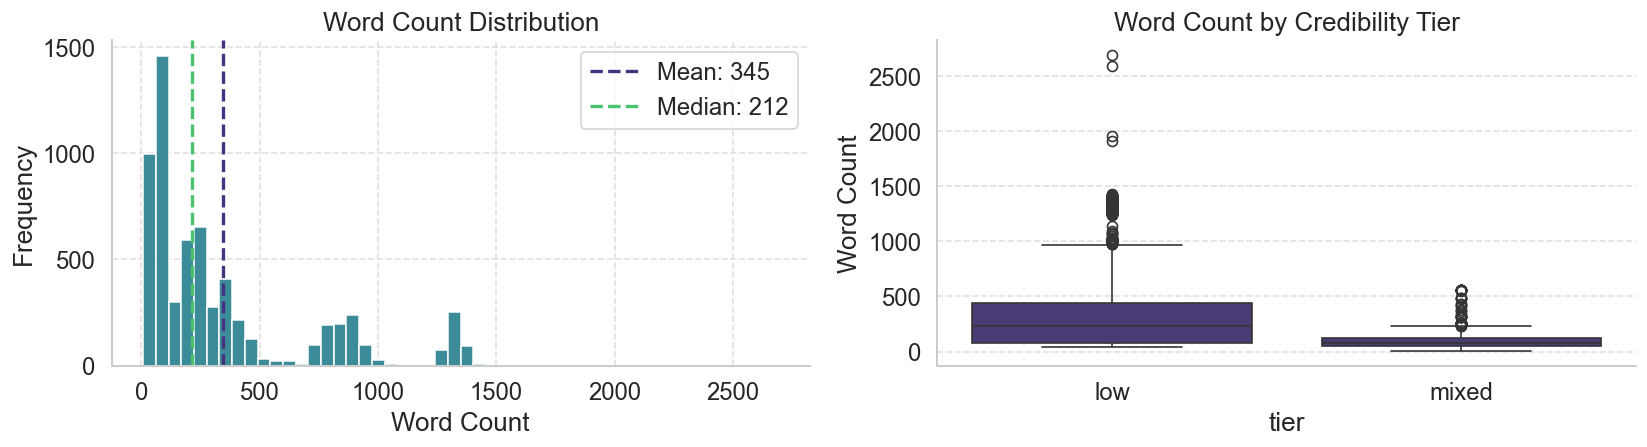


Word count by tier:
        count        mean         std   min   25%    50%     75%     max
tier                                                                    
low    5885.0  364.608836  379.736258  38.0  81.0  228.0  438.00  2691.0
mixed   508.0  114.667323  103.408754   8.0  52.0   76.0  124.25   558.0


In [56]:
# Visualize word count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(ok_df['word_count'], bins=50, color=viridis_palette[2], edgecolor='white', alpha=0.9)
axes[0].axvline(ok_df['word_count'].mean(), color=viridis_palette[0], linestyle='--', linewidth=2,
                label=f"Mean: {ok_df['word_count'].mean():.0f}")
axes[0].axvline(ok_df['word_count'].median(), color=viridis_palette[4], linestyle='--', linewidth=2,
                label=f"Median: {ok_df['word_count'].median():.0f}")
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution')
axes[0].legend()

# Box plot by tier (uses global viridis palette)
sns.boxplot(data=ok_df, x='tier', y='word_count', ax=axes[1])
axes[1].set_title('Word Count by Credibility Tier')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

print("\nWord count by tier:")
print(ok_df.groupby('tier')['word_count'].describe())

## 4. Temporal Patterns

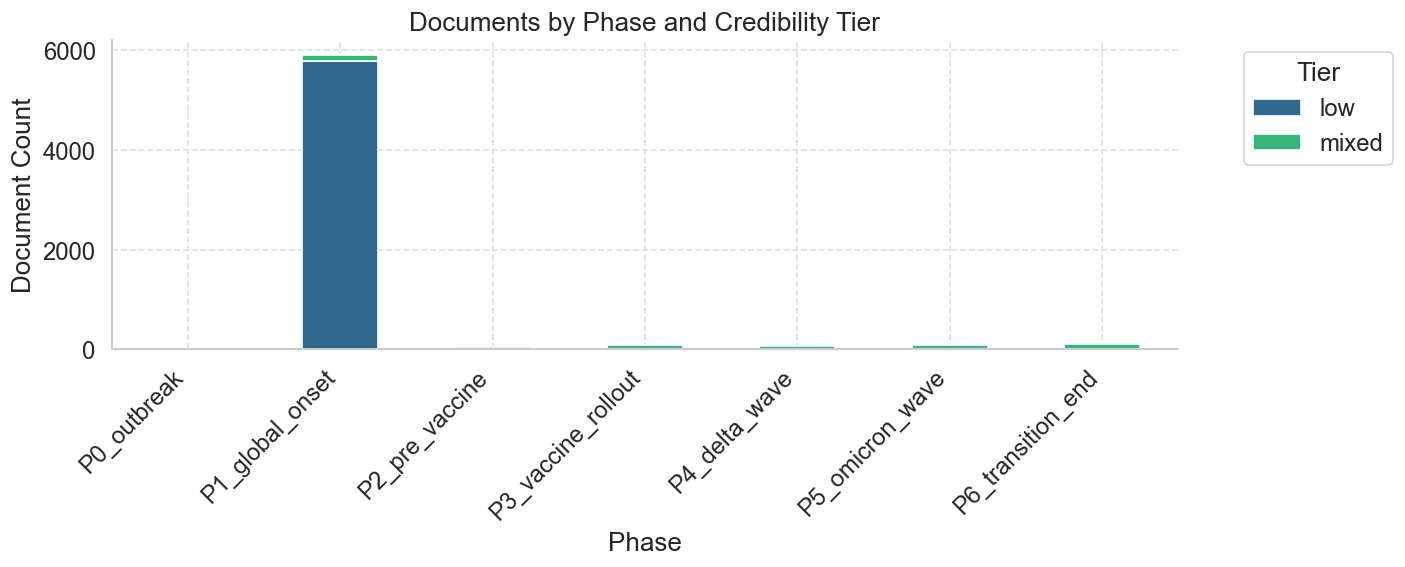


Document counts by phase and tier:
tier                 low  mixed
phase                          
P0_outbreak            0      7
P1_global_onset     5790    121
P2_pre_vaccine         0     45
P3_vaccine_rollout     0     82
P4_delta_wave          0     75
P5_omicron_wave        0     83
P6_transition_end      0    105


In [57]:
# Phase progression
phase_order = [p.name for p in PHASES_BY_NAME.values()]
df['phase_num'] = df['phase'].map({p: i for i, p in enumerate(phase_order)})

fig, ax = plt.subplots(figsize=(12, 5))

# Group by phase and tier
phase_tier_counts = df.groupby(['phase', 'tier']).size().unstack(fill_value=0)
# Reorder by phase
phase_tier_counts = phase_tier_counts.loc[phase_order]

n_tiers = len(phase_tier_counts.columns)
phase_tier_counts.plot(
    kind='bar', stacked=True, ax=ax,
    color=sns.color_palette("viridis", n_colors=n_tiers),
    edgecolor='white',
)
ax.set_xlabel('Phase')
ax.set_ylabel('Document Count')
ax.set_title('Documents by Phase and Credibility Tier')
ax.legend(title='Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nDocument counts by phase and tier:")
print(phase_tier_counts)

## 5. Top Domains

In [58]:
# Extract domain from seed_url
def extract_domain(url):
    if not url:
        return None
    parsed = urlparse(url) if '://' in url else urlparse(f'http://{url}')
    hostname = parsed.hostname or parsed.netloc
    return hostname.lower() if hostname else None

df['domain'] = df['seed_url'].apply(extract_domain)

print("\n=== Top 20 Domains (Overall) ===")
top_domains = df['domain'].value_counts().head(20)
for domain, count in top_domains.items():
    tier = df[df['domain'] == domain]['tier'].mode()[0] if len(df[df['domain'] == domain]) > 0 else 'unknown'
    print(f"  {domain}: {count} ({tier})")


=== Top 20 Domains (Overall) ===


  bigleaguepolitics.com: 761 (low)
  dcclothesline.com: 544 (low)
  rushlimbaugh.com: 504 (low)
  mercola.com: 473 (low)
  themindunleashed.com: 465 (low)
  sott.net: 440 (low)
  zerohedge.com: 382 (low)
  intellihub.com: 374 (low)
  naturalhealth365.com: 372 (low)
  biased.news: 284 (low)
  banned.news: 280 (low)
  humansarefree.com: 256 (low)
  cdc.news: 171 (low)
  infowars.com: 146 (low)
  californiacollapse.news: 134 (low)
  www.who.int: 124 (mixed)
  www.cdc.gov: 116 (mixed)
  greenmedinfo.com: 112 (low)
  censorship.news: 72 (low)
  www.unicef.org: 58 (mixed)


In [59]:
# Top domains per tier
for tier in sorted(df['tier'].unique()):
    tier_df = df[df['tier'] == tier]
    print(f"\n=== Top Domains: {tier} (n={len(tier_df)}) ===")
    top_domains = tier_df['domain'].value_counts().head(10)
    for domain, count in top_domains.items():
        print(f"  {domain}: {count}")


=== Top Domains: low (n=5976) ===
  bigleaguepolitics.com: 761
  dcclothesline.com: 544
  rushlimbaugh.com: 504
  mercola.com: 473
  themindunleashed.com: 465
  sott.net: 440
  zerohedge.com: 382
  intellihub.com: 374
  naturalhealth365.com: 372
  biased.news: 284

=== Top Domains: mixed (n=518) ===
  www.who.int: 124
  www.cdc.gov: 116
  www.unicef.org: 58
  www.redcross.org: 56
  www.covid19treatmentguidelines.nih.gov: 48
  www.unhcr.org: 24
  www.rescue.org: 23
  www.aarp.org: 16
  samaritanspurse.org: 16
  wck.org: 10


## 6. Language Distribution


=== Languages (n=6393) ===


IndexError: index 0 is out of bounds for axis 0 with size 0

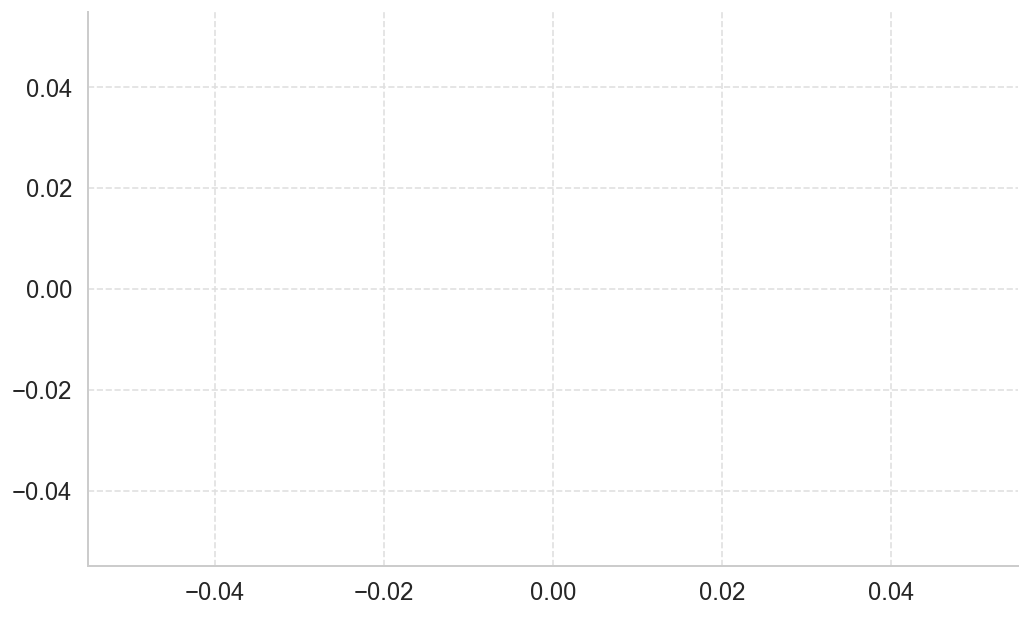

In [60]:
# Language distribution (for successful extractions)
ok_df = df[df['fetch_status'] == 'ok']
print(f"\n=== Languages (n={len(ok_df)}) ===")
lang_counts = ok_df['language'].value_counts().head(15)
for lang, count in lang_counts.items():
    pct = 100 * count / len(ok_df)
    print(f"  {lang}: {count} ({pct:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
lang_counts.plot(kind='barh', ax=ax, color=viridis_palette[2], edgecolor='white')
ax.set_xlabel('Count')
ax.set_title('Top Languages in Extracted Documents')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Sample Document Preview

In [ ]:
# Show a few sample documents
sample_df = ok_df.sample(min(3, len(ok_df)), random_state=42)

for idx, (_, row) in enumerate(sample_df.iterrows()):
    print(f"\n{'='*80}")
    print(f"Sample {idx+1}: {row['collection_id']} | {row['phase']} | {row['tier']}")
    print(f"URL: {row['seed_url']}")
    print(f"Title: {row['title'][:100] if row['title'] else 'N/A'}")
    print(f"Word count: {row['word_count']} | Extraction: {row['extraction_mode']}")
    print(f"\nText preview:")
    text = row.get('text', '')[:300]
    print(f"{text}..." if len(text) == 300 else text)


Sample 1: 13559 | P1_global_onset | low
URL: http://zerohedge.com/
Title: NYT 'Chief Threat To Democracy': Eric Weinstein Takes Flamethrower To Paper Of Record After Bari Wei
Word count: 214 | Extraction: article

Text preview:
"This is not a normal recession. The recessionary part of this you’re going to see down the road. You will see the effect of this recession. You’re just not going to see it right away because of all the stimulus."
No matter where in the world you log in from - Silicon Valley, London, and beyond - CO...

Sample 2: 13559 | P1_global_onset | low
URL: http://biased.news/
Title: Biased News | Biased News – Biased Information
Word count: 842 | Extraction: article

Text preview:
absurd
newsfakes
biased
lies
honest
journalism
07/29/2020
/
News Editors
Twitter suspends PragerU, prominent conservatives, and doctors for commenting on HCQ
07/29/2020
/
Ethan Huff
Google directly interfering with 2020 election by censoring alt-news websites
07/29/2020
/
S.D. Wells
Covid trut